# **Step 1 – Import Libraries**

In [1]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import os
import random
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


# **Step 2 – Define Project Paths**

In [2]:
# ============================================================
# Step 2: Define Project Paths
# ============================================================

import os

DATASET_PATH = "../Dataset"

MODEL_PATH = "../models/best.pt"

DATA_YAML = "../Dataset/data.yaml"

TEST_IMAGES = "../Dataset/test/images"

TEST_LABELS = "../Dataset/test/labels"

RESULTS_DIR = "../results/predictions"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*60)
print("Project Paths")
print("="*60)

print(f"Dataset Path : {DATASET_PATH}")
print(f"Model Path   : {MODEL_PATH}")
print(f"Data YAML    : {DATA_YAML}")
print(f"Test Images  : {TEST_IMAGES}")
print(f"Test Labels  : {TEST_LABELS}")
print(f"Results Path : {RESULTS_DIR}")

Project Paths
Dataset Path : ../Dataset
Model Path   : ../models/best.pt
Data YAML    : ../Dataset/data.yaml
Test Images  : ../Dataset/test/images
Test Labels  : ../Dataset/test/labels
Results Path : ../results/predictions


# **Step 3 – Check Files & Folders**

In [3]:
# ============================================================
# Step 3: Check Required Files & Folders
# ============================================================

print("="*60)
print("Checking Required Files")
print("="*60)

required_paths = {
    "Dataset Folder": DATASET_PATH,
    "Model": MODEL_PATH,
    "Data YAML": DATA_YAML,
    "Test Images": TEST_IMAGES,
    "Test Labels": TEST_LABELS,
}

for name, path in required_paths.items():
    if os.path.exists(path):
        print(f"✓ {name} Found")
    else:
        print(f"✗ {name} Missing")

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

test_images = [
    img for img in os.listdir(TEST_IMAGES)
    if img.lower().endswith(image_extensions)
]

print("\n" + "="*60)
print(f"Total Test Images : {len(test_images)}")
print("="*60)

Checking Required Files
✓ Dataset Folder Found
✓ Model Found
✓ Data YAML Found
✓ Test Images Found
✓ Test Labels Found

Total Test Images : 5757


# **Step 4 – Load Trained YOLO Model**

In [4]:
# ============================================================
# Step 4: Load Trained YOLO Model
# ============================================================

from ultralytics import YOLO

print("="*60)
print("Loading YOLOv8 Model")
print("="*60)

model = YOLO(MODEL_PATH)

print("✓ Model Loaded Successfully")
print(model)

Loading YOLOv8 Model
✓ Model Loaded Successfully
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    

# **Step 5 – Predict on Single Test Image**

In [5]:
# ============================================================
# Step 5: Predict on Single Test Image
# ============================================================

import os
import random

print("="*60)
print("Predicting on Single Test Image")
print("="*60)

# Get all test images
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

test_images = [
    img for img in os.listdir(TEST_IMAGES)
    if img.lower().endswith(image_extensions)
]

# Select random image
random_image = random.choice(test_images)
image_path = os.path.join(TEST_IMAGES, random_image)

print(f"Selected Image: {random_image}")
print(f"Image Path: {image_path}")
print()

# Run prediction
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    save=True,
    project=RESULTS_DIR,
    name="single_prediction",
    exist_ok=True,
    verbose=True
)

print("\nPrediction Completed Successfully")

# Check where results are saved
save_dir = results[0].save_dir

print(f"\nPrediction Save Directory: {save_dir}")

if os.path.exists(save_dir):
    print("\nFiles Saved:")
    print(os.listdir(save_dir))
else:
    print("\nPrediction folder not found!")

Predicting on Single Test Image
Selected Image: Japan_004799.jpg
Image Path: ../Dataset/test/images\Japan_004799.jpg


image 1/1 d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\..\Dataset\test\images\Japan_004799.jpg: 640x640 1 D10, 1 D40, 151.2ms
Speed: 5.8ms preprocess, 151.2ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\single_prediction

Prediction Completed Successfully

Prediction Save Directory: D:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\single_prediction

Files Saved:
['China_MotorBike_000551.jpg', 'Japan_004799.jpg', 'Japan_011296.jpg']


# **Step 6 – Display Prediction Result**

Prediction Image: D:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\single_prediction\Japan_004799.jpg


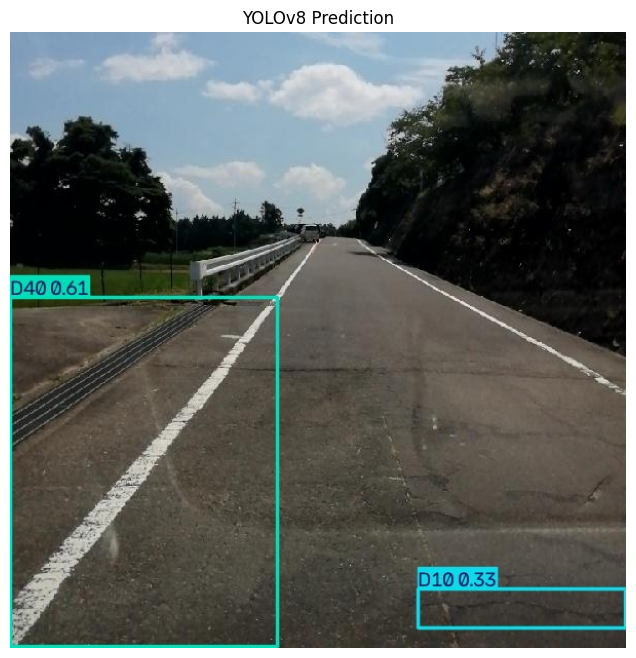

In [6]:
# ============================================================
# Step 6: Display Prediction Result
# ============================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

# Prediction image path
prediction_image = os.path.join(results[0].save_dir, random_image)

print("Prediction Image:", prediction_image)

# Display image
img = Image.open(prediction_image)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title("YOLOv8 Prediction")
plt.axis("off")
plt.show()

# **Step 7 – Predict on All Test Images**

In [19]:
# ============================================================
# Step 7: Predict on All Test Images (Memory Efficient)
# ============================================================

import os

print("="*60)
print("Predicting on All Test Images")
print("="*60)

results_generator = model.predict(
    source=TEST_IMAGES,
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project=RESULTS_DIR,
    name="batch_prediction",
    exist_ok=True,
    stream=True,      # Prevents RAM overflow
    verbose=False
)

total_images = 0

for result in results_generator:
    total_images += 1

print("\nBatch Prediction Completed Successfully!")
print(f"Total Images Processed : {total_images}")

# ============================================================
# Save prediction folder path for next steps
# ============================================================

prediction_folder = os.path.join(
    os.getcwd(),
    "runs",
    "results",
    "predictions",
    "batch_prediction"
)

print(f"\nPrediction Folder : {prediction_folder}")

if os.path.exists(prediction_folder):
    print("✓ Prediction folder found.")
else:
    print("✗ Prediction folder not found.")

Predicting on All Test Images
Results saved to D:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction
3568 labels saved to D:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction\labels

Batch Prediction Completed Successfully!
Total Images Processed : 5757

Prediction Folder : d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction
✓ Prediction folder found.


# **Step 8 – Display Random Prediction Results**

Displaying Random Prediction Results
Total Prediction Images : 5757


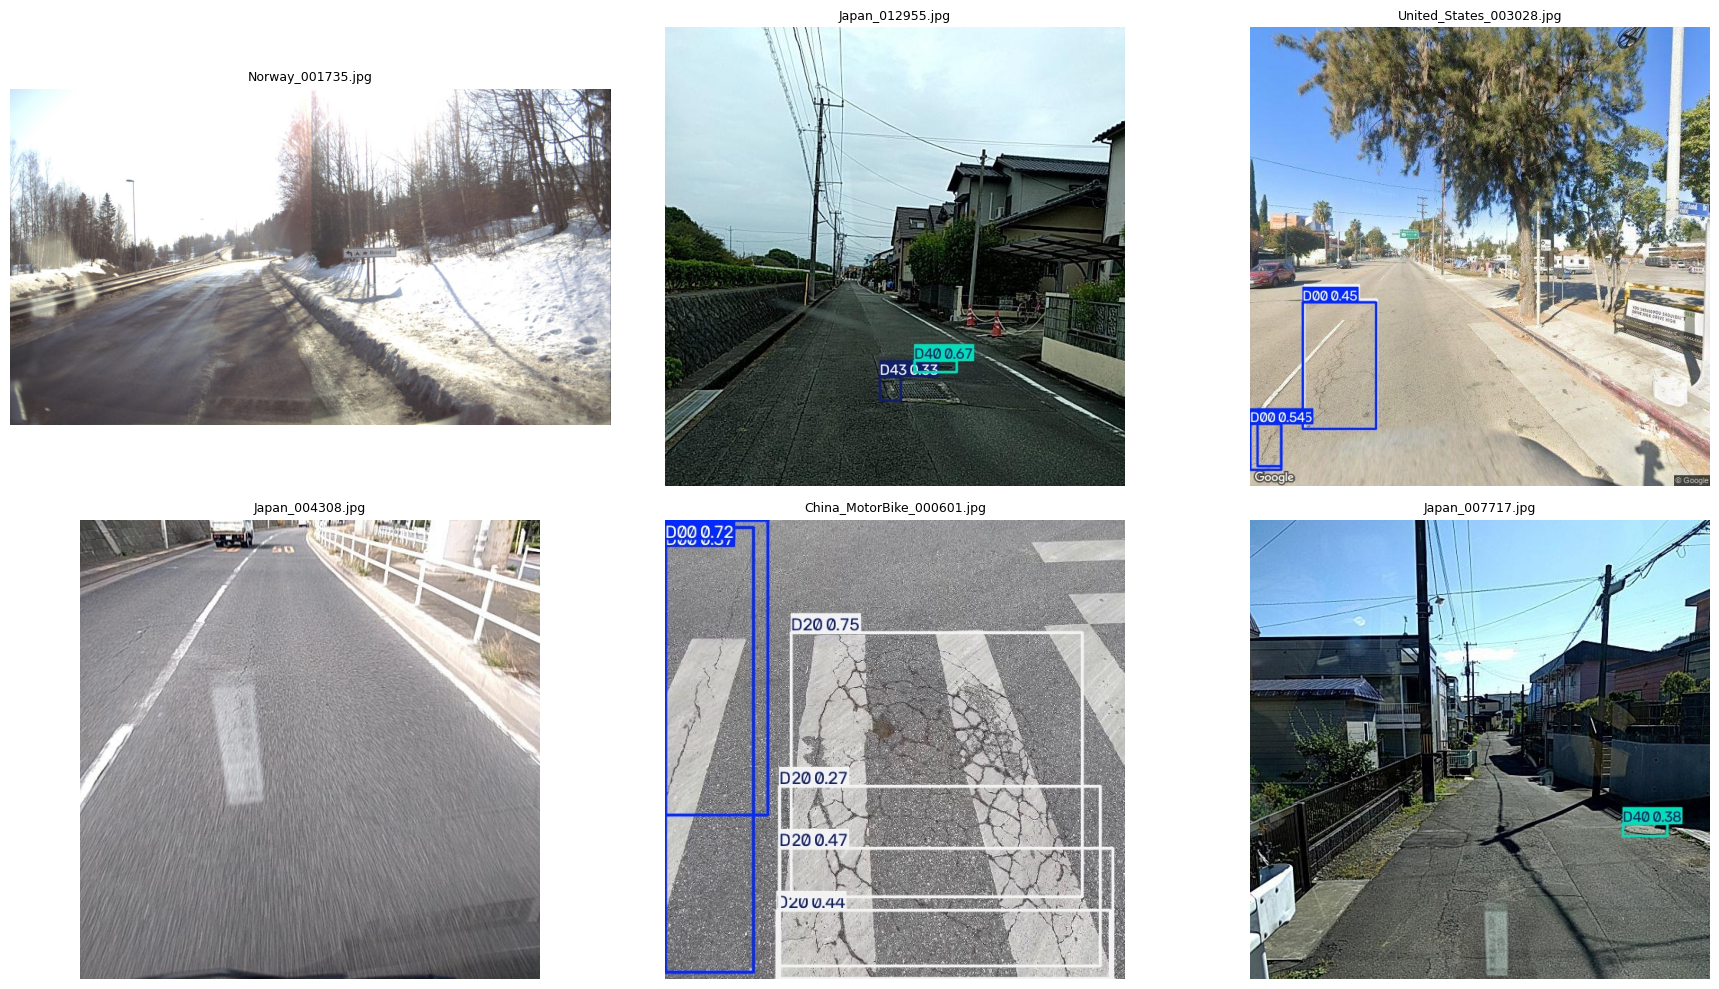

In [20]:
# ============================================================
# Step 8: Display Random Prediction Results
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

print("="*60)
print("Displaying Random Prediction Results")
print("="*60)

prediction_images = [
    img for img in os.listdir(prediction_folder)
    if img.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Total Prediction Images : {len(prediction_images)}")

random_predictions = random.sample(
    prediction_images,
    min(6, len(prediction_images))
)

plt.figure(figsize=(18,10))

for i, img_name in enumerate(random_predictions):

    img_path = os.path.join(prediction_folder, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Step 9 – Generate Prediction Summary (CSV)**

In [21]:
# ============================================================
# Step 9: Generate Prediction Summary (CSV)
# ============================================================

import os
import pandas as pd

print("="*60)
print("Generating Prediction Summary")
print("="*60)

labels_folder = os.path.join(prediction_folder, "labels")

summary = []

for label_file in sorted(os.listdir(labels_folder)):

    if label_file.endswith(".txt"):

        label_path = os.path.join(labels_folder, label_file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        summary.append({
            "Image Name": label_file.replace(".txt", ".jpg"),
            "Detected Objects": len(lines)
        })

prediction_df = pd.DataFrame(summary)

csv_path = os.path.join(
    prediction_folder,
    "prediction_summary.csv"
)

prediction_df.to_csv(csv_path, index=False)

print(f"Total Images with Detections : {len(prediction_df)}")
print(f"CSV Saved Successfully")

print(f"CSV Path : {csv_path}")

display(prediction_df.head(10))

Generating Prediction Summary
Total Images with Detections : 3568
CSV Saved Successfully
CSV Path : d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction\prediction_summary.csv


,Image Name,Detected Objects
0,China_Drone_000017.jpg,3
1,China_Drone_000040.jpg,3
2,China_Drone_000052.jpg,3
3,China_Drone_000075.jpg,3
4,China_Drone_000085.jpg,3
5,China_Drone_000092.jpg,6
6,China_Drone_000096.jpg,3
7,China_Drone_000098.jpg,3
8,China_Drone_000099.jpg,6
9,China_Drone_000101.jpg,6


# **Step 10 – Final Project Summary**

In [23]:
# ============================================================
# Step 10: Final Project Summary
# ============================================================

import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

total_test_images = len([
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith(image_extensions)
])

print("="*70)
print("ROAD DAMAGE DETECTION USING YOLOv8")
print("="*70)

print(f"Model File               : {MODEL_PATH}")
print(f"Dataset Path             : {DATASET_PATH}")
print(f"Test Images Folder       : {TEST_IMAGES}")

print("-"*70)

print(f"Total Test Images        : {total_test_images}")
print(f"Images Predicted         : {total_images}")
print(f"Images with Detections   : {len(prediction_df)}")

print("-"*70)

print(f"Prediction Folder        : {prediction_folder}")
print(f"Prediction Labels        : {labels_folder}")
print(f"Prediction Summary CSV   : {csv_path}")

print("="*70)
print("Prediction Notebook Completed Successfully")
print("="*70)

ROAD DAMAGE DETECTION USING YOLOv8
Model File               : ../models/best.pt
Dataset Path             : ../Dataset
Test Images Folder       : ../Dataset/test/images
----------------------------------------------------------------------
Total Test Images        : 5757
Images Predicted         : 5757
Images with Detections   : 3568
----------------------------------------------------------------------
Prediction Folder        : d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction
Prediction Labels        : d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction\labels
Prediction Summary CSV   : d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\runs\results\predictions\batch_prediction\prediction_summary.csv
Prediction Notebook Completed Successfully
